# SensorGuard — Predictive Anomaly Detection on Time-Series Sensor Data

An end-to-end ML pipeline on NASA CMAPSS industrial turbofan engine sensor data.
We engineer temporal features, train and benchmark three models (Isolation Forest, Random Forest, SVM),
and simulate a real-world shadow-mode deployment for production ML validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
train_df = pd.read_csv('data/train_FD001.txt', sep=' ', header=None, names=cols)
train_df = train_df.dropna(axis=1)
print(train_df.shape)
train_df.head()

(23867, 26)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.000714,-0.000321,100.013674,518.759628,642.388302,1592.141967,1399.824723,14.609240,...,521.551472,2388.008275,8138.076238,8.442462,0.030486,392.384598,2387.668325,99.997042,38.024825,23.401044
1,1,2,0.000840,-0.000429,100.009583,518.672117,641.591516,1589.033027,1400.305436,14.622158,...,522.024596,2387.823972,8137.820201,8.458487,0.028262,392.189928,2388.260084,100.015881,38.070470,23.432109
2,1,3,0.000695,-0.000037,100.002273,518.663395,641.763504,1587.369327,1401.176400,14.618199,...,521.562227,2389.052917,8136.776018,8.431125,0.029106,392.152570,2387.889051,99.999222,38.143101,23.421418
3,1,4,-0.000678,-0.000082,100.007480,518.819584,641.207532,1589.170971,1401.017336,14.625324,...,521.656855,2387.803439,8138.675697,8.463898,0.028695,392.489175,2387.901619,99.998134,38.043387,23.402079
4,1,5,-0.000649,-0.000063,100.010051,518.767277,641.864476,1586.583548,1395.136573,14.639293,...,522.187275,2388.921326,8138.409451,8.429195,0.031348,391.687864,2388.052396,100.009109,38.108035,23.431602


## Create Labels (Remaining Useful Life)

We compute the Remaining Useful Life (RUL) for each engine cycle and create a binary failure label:
- **1** = Failure imminent (RUL ≤ 30 cycles)
- **0** = Normal operation

In [2]:
max_cycle = train_df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
train_df = train_df.merge(max_cycle, on='unit')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df['failure'] = (train_df['RUL'] <= 30).astype(int)

print(train_df['failure'].value_counts())
print(f"Failure rate: {train_df['failure'].mean():.2%}")

failure
0    20767
1     3100
Name: count, dtype: int64
Failure rate: 12.99%


## Feature Engineering (Lag + Rolling Statistics)

We engineer temporal features to capture degradation patterns:
- **Rolling mean** (window=5): Smoothed sensor trends
- **Rolling std** (window=5): Volatility / instability signal
- **Lag-1**: Previous cycle's sensor reading for change detection

In [3]:
sensor_cols = [f's{i}' for i in range(1, 22) if f's{i}' in train_df.columns]

for col in sensor_cols:
    train_df[f'{col}_roll_mean'] = train_df.groupby('unit')[col].transform(
        lambda x: x.rolling(5, min_periods=1).mean())
    train_df[f'{col}_roll_std'] = train_df.groupby('unit')[col].transform(
        lambda x: x.rolling(5, min_periods=1).std().fillna(0))

for col in sensor_cols:
    train_df[f'{col}_lag1'] = train_df.groupby('unit')[col].shift(1).fillna(0)

print(f"Features after engineering: {train_df.shape[1]}")

Features after engineering: 92


## EDA — Sensor Trends & Class Distribution

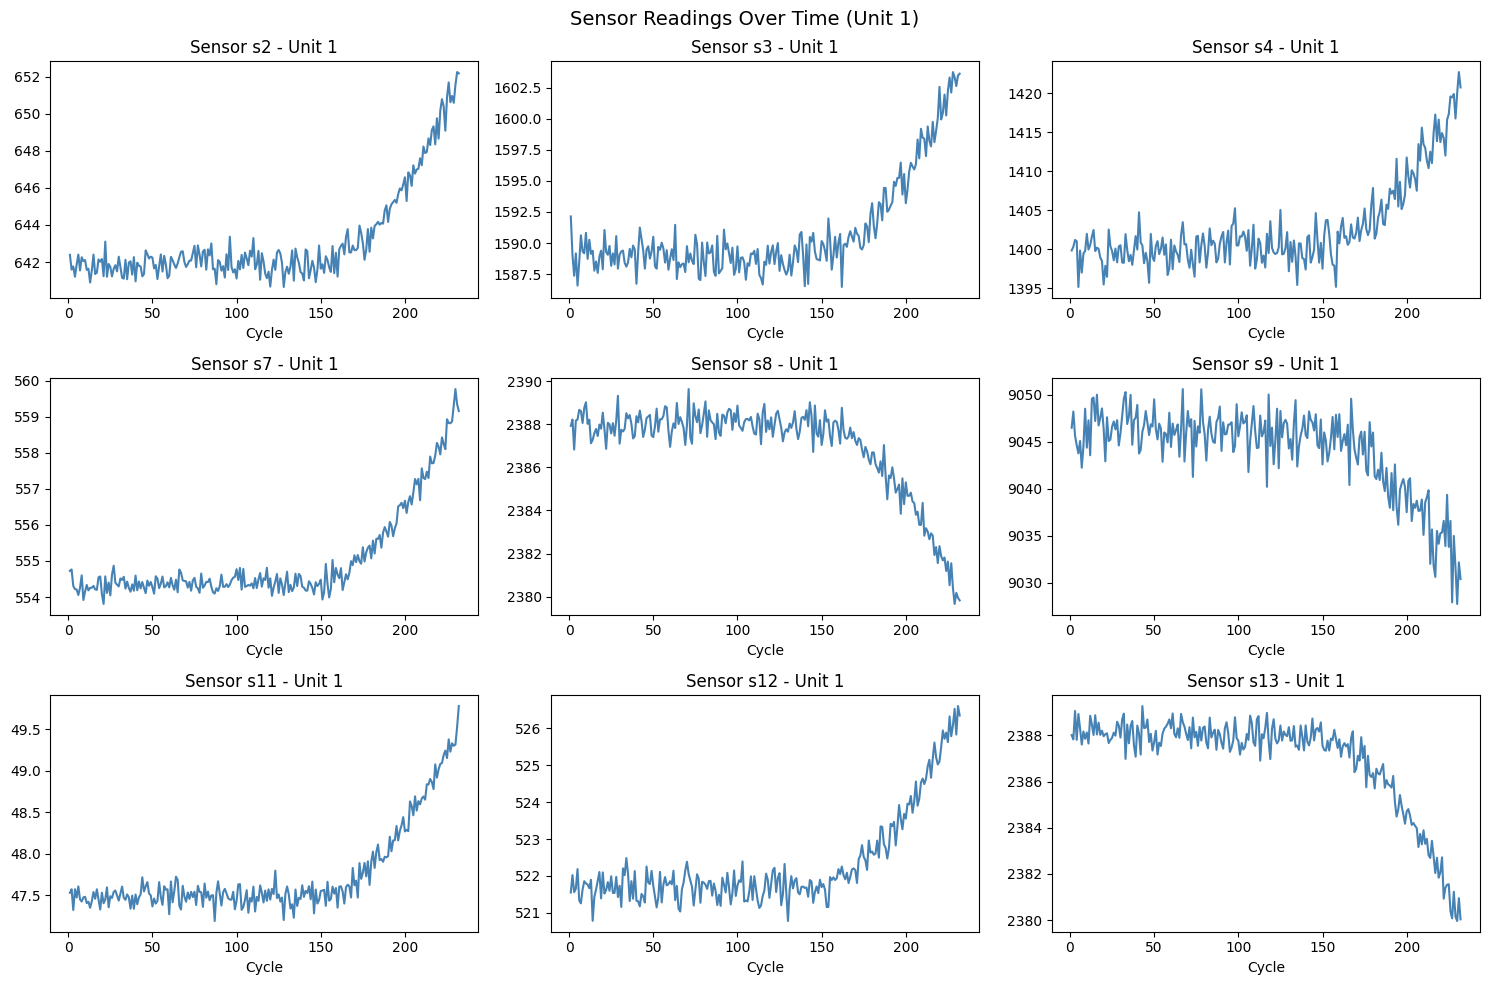

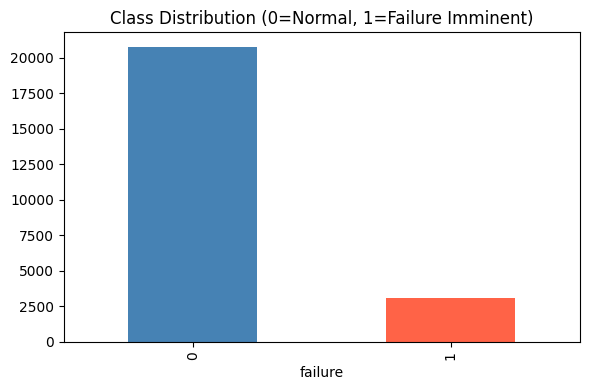

In [4]:
unit1 = train_df[train_df['unit'] == 1]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(['s2','s3','s4','s7','s8','s9','s11','s12','s13']):
    axes[i//3][i%3].plot(unit1['cycle'], unit1[col], color='steelblue')
    axes[i//3][i%3].set_title(f'Sensor {col} - Unit 1')
    axes[i//3][i%3].set_xlabel('Cycle')
plt.suptitle('Sensor Readings Over Time (Unit 1)', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
train_df['failure'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution (0=Normal, 1=Failure Imminent)')
plt.tight_layout()
plt.show()

## Prepare Features & Train/Test Split

In [5]:
feature_cols = sensor_cols + \
    [f'{c}_roll_mean' for c in sensor_cols] + \
    [f'{c}_roll_std' for c in sensor_cols] + \
    [f'{c}_lag1' for c in sensor_cols]

X = train_df[feature_cols]
y = train_df['failure']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (19093, 84), Test: (4774, 84)


## Train & Benchmark Models

In [6]:
results = {}

# Isolation Forest
iso = IsolationForest(contamination=0.15, random_state=42, n_jobs=-1)
iso.fit(X_train)
iso_preds = np.where(iso.predict(X_test) == -1, 1, 0)
results['Isolation Forest'] = {'F1': f1_score(y_test, iso_preds),
    'Precision': precision_score(y_test, iso_preds), 'Recall': recall_score(y_test, iso_preds)}

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results['Random Forest'] = {'F1': f1_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds), 'Recall': recall_score(y_test, rf_preds)}

# SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
results['SVM'] = {'F1': f1_score(y_test, svm_preds),
    'Precision': precision_score(y_test, svm_preds), 'Recall': recall_score(y_test, svm_preds)}

results_df = pd.DataFrame(results).T
print(results_df.round(4))

                      F1  Precision  Recall
Isolation Forest  0.8486     0.7892  0.9177
Random Forest     0.9071     0.9334  0.8823
SVM               0.9181     0.9423  0.8952


## Model Comparison & Classification Report

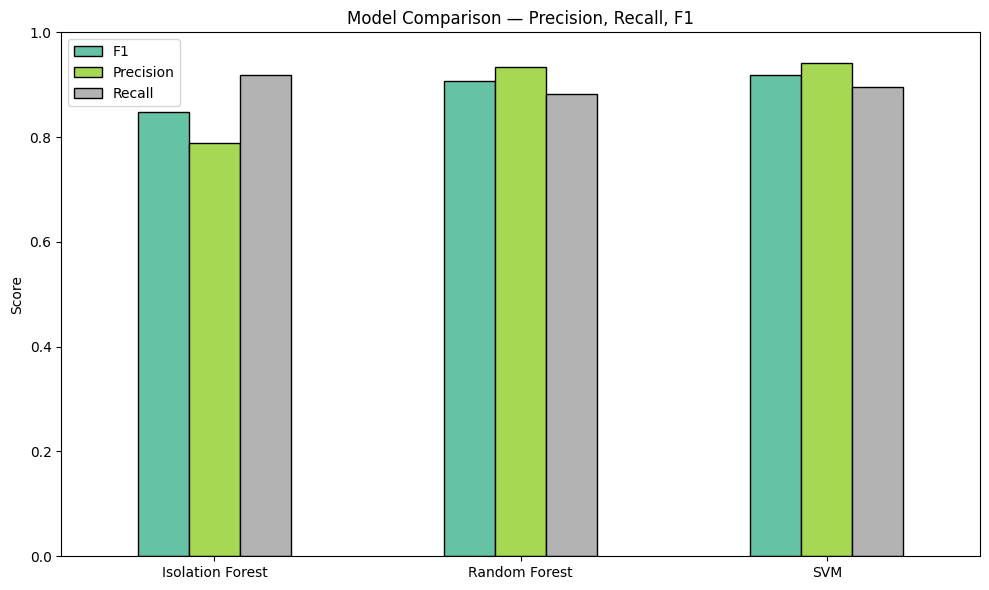

Best Model — Random Forest
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      4154
     Failure       0.93      0.88      0.91       620

    accuracy                           0.98      4774
   macro avg       0.96      0.94      0.95      4774
weighted avg       0.98      0.98      0.98      4774



Cross-Val F1: 0.8909 ± 0.0073


In [7]:
results_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Precision, Recall, F1')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print('Best Model — Random Forest')
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Failure']))

cv = cross_val_score(rf, X_scaled, y, cv=5, scoring='f1')
print(f"Cross-Val F1: {cv.mean():.4f} ± {cv.std():.4f}")

## Shadow-Mode Deployment Simulation

We hold out the last 20% of cycles per unit as "live" production data and validate
model predictions against ground-truth failure labels — mirroring real-world ML deployment.

In [8]:
train_df_sorted = train_df.sort_values(['unit', 'cycle'])
cutoff = int(len(train_df_sorted) * 0.8)
shadow_train = train_df_sorted.iloc[:cutoff]
shadow_test  = train_df_sorted.iloc[cutoff:]

X_shadow_train = scaler.fit_transform(shadow_train[feature_cols])
X_shadow_test  = scaler.transform(shadow_test[feature_cols])
y_shadow_test  = shadow_test['failure']

rf_shadow = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shadow.fit(X_shadow_train, shadow_train['failure'])
shadow_preds = rf_shadow.predict(X_shadow_test)

print('Shadow Mode Validation Results:')
print(classification_report(y_shadow_test, shadow_preds, target_names=['Normal','Failure']))

Shadow Mode Validation Results:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      4185
     Failure       0.88      0.90      0.89       589

    accuracy                           0.97      4774
   macro avg       0.93      0.94      0.94      4774
weighted avg       0.97      0.97      0.97      4774

